In [1]:
import pandas as pd
import optuna
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, roc_auc_score, confusion_matrix
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
import matplotlib as mpl
from matplotlib import font_manager
import math
import lightgbm as lgb
import numpy as np

pd.set_option('display.max_columns', None)
data_path = '/data/home/yansn/naojiye/data/final_data/filtered_patient2.csv'
filtered_df = pd.read_csv(data_path)
filtered_df.shape

/data/home/yansn/anaconda3/envs/naojiye/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(887, 232)

In [2]:
filtered_df = filtered_df[['Unnamed: 0', 'patientId','血_隐球菌荚膜抗原_定性','脑脊液_葡萄糖_定量','脑脊液_淋巴细胞百分比_定量','血_肌酸激酶_定量', '分组', '组名']]

In [3]:
import re
# 替换特征名中的 [，]
def clean_feature_names_simple(feature_names):
    cleaned_names = []
    for name in feature_names:
        cleaned_name = name.replace('[', '').replace(']', '').replace('<', '').replace('>', '').replace('.', '').replace('(', '').replace(')', '').replace(':', '').replace(',', '').replace('"', '').replace('\\', '')
        cleaned_names.append(cleaned_name)
    return cleaned_names


# 对 DataFrame 的列名进行清洗
filtered_df.columns = clean_feature_names_simple(filtered_df.columns)
# filtered_df.columns = [clean_feature_names_simple(col) for col in filtered_df.columns]
print("清洗后的列名:", filtered_df.columns.tolist())

清洗后的列名: ['Unnamed 0', 'patientId', '血_隐球菌荚膜抗原_定性', '脑脊液_葡萄糖_定量', '脑脊液_淋巴细胞百分比_定量', '血_肌酸激酶_定量', '分组', '组名']


In [4]:
# 感染性脑膜炎细化区分：2是一类，134是一类

# 1. 数据预处理：将 'gender' 列转换为数值型
# filtered_df['gender'] = filtered_df['gender'].map({'女': 0, '男': 1})

# 去除阴性组（0）和病毒性脑炎（8）病状
filtered_df = filtered_df[filtered_df['分组'].isin([1,2,3,4])]

# 选择特征 将数据正例和反例平均分配
filter_1 = filtered_df[filtered_df["分组"]==2]
filter_2 = filtered_df[filtered_df["分组"].isin([1,3,4])]

X_1 = filter_1[list(filter_1.columns)[2:-2]]
X_2 = filter_2[list(filter_2.columns)[2:-2]]

# 标签（分组，2 类与其他类）
y_1 = (filter_1['分组']==2).astype(int)# 如果分组为 2，标签为 1，否则为 0
y_2 = (filter_2['分组']==2).astype(int) 

# 拆分数据集为训练集（60%）、验证集（20%）和测试集（20%）
X_train_1, X_temp_1, y_train_1, y_temp_1 = train_test_split(X_1, y_1, test_size=0.4, random_state=42)
X_val_1, X_test_1, y_val_1, y_test_1 = train_test_split(X_temp_1, y_temp_1, test_size=0.5, random_state=42)

X_train_2, X_temp_2, y_train_2, y_temp_2 = train_test_split(X_2, y_2, test_size=0.4, random_state=42)
X_val_2, X_test_2, y_val_2, y_test_2 = train_test_split(X_temp_2, y_temp_2, test_size=0.5, random_state=42)

# 将正例与反例拼接
X_train = pd.concat([X_train_1,X_train_2])
y_train = pd.concat([y_train_1,y_train_2])

X_val = pd.concat([X_val_1,X_val_2])
y_val = pd.concat([y_val_1,y_val_2])

X_test = pd.concat([X_test_1,X_test_2])
y_test = pd.concat([y_test_1,y_test_2])


# 定义 Optuna 目标函数
def objective(trial):
    # 建议超参数范围
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'n_estimators': trial.suggest_int('n_estimators', 50, 500, step=50),
        'num_leaves': trial.suggest_int('num_leaves', 20, 300, step=10),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'random_state': 42
    }
    
    # 添加类别权重处理不平衡数据（可选）
    if trial.suggest_categorical('use_scale_pos_weight', [True, False]):
        scale_pos_weight = np.sum(y_train == 0) / np.sum(y_train == 1)
        params['scale_pos_weight'] = scale_pos_weight
    
    # 训练模型
    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)],  # 早停防止过拟合
        # verbose=False
    )
    
    # 预测验证集概率
    y_val_pred_proba = model.predict_proba(X_val)[:, 1]
    
    # 计算 AUC
    auc_score = roc_auc_score(y_val, y_val_pred_proba)
    
    # 由于 Optuna 默认最小化目标函数，我们返回 1 - AUC 来最大化 AUC
    return 1.0 - auc_score

# 创建 Optuna 研究
study = optuna.create_study(
    direction='minimize',  # 最小化目标函数 (1 - AUC)
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10)  # 10轮后开始剪枝
)

# 运行优化
print("开始超参数优化...")
study.optimize(objective, n_trials=100, show_progress_bar=True)

# 输出最佳结果
print("\n优化完成!")
print("Number of finished trials: ", len(study.trials))
print("Best trial:")
best_trial = study.best_trial
print(f"  Best AUC: {1 - best_trial.value:.4f}")  # 转换回 AUC
print("  Best params: ")
for key, value in best_trial.params.items():
    print(f"    {key}: {value}")

# 使用最佳参数重新训练最终模型
print("\n使用最佳参数训练最终模型...")
best_params = {k: v for k, v in best_trial.params.items() if k != 'use_scale_pos_weight'}
best_params['random_state'] = 42
best_params['objective'] = 'binary'
best_params['verbosity'] = -1

# 如果使用了类别权重，添加回参数
if 'use_scale_pos_weight' in best_trial.params and best_trial.params['use_scale_pos_weight']:
    best_params['scale_pos_weight'] = np.sum(y_train == 0) / np.sum(y_train == 1)

final_model = lgb.LGBMClassifier(**best_params)
final_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(stopping_rounds=20)],
    # verbose=False
)

# 在各个数据集上评估最终模型
def evaluate_model(model, X, y, dataset_name):
    y_pred = model.predict(X)
    y_pred_proba = model.predict_proba(X)[:, 1]
    
    auc = roc_auc_score(y, y_pred_proba)
    accuracy = accuracy_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    
    print(f"\n{dataset_name} 集评估结果:")
    print(f"AUC: {auc:.4f}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1-score: {f1:.4f}")
    
    # 打印混淆矩阵
    cm = confusion_matrix(y, y_pred)
    print("Confusion Matrix:")
    print(cm)
    
    return auc, accuracy, f1

# 评估训练集、验证集和测试集
train_auc, train_acc, train_f1 = evaluate_model(final_model, X_train, y_train, "训练")
val_auc, val_acc, val_f1 = evaluate_model(final_model, X_val, y_val, "验证")
test_auc, test_acc, test_f1 = evaluate_model(final_model, X_test, y_test, "测试")

# 可选：保存最佳模型
# import joblib
# joblib.dump(final_model, 'best_lgb_model.pkl')
# print("\n最佳模型已保存为 'best_lgb_model.pkl'")

# 可选：绘制特征重要性
# import matplotlib.pyplot as plt

# plt.figure(figsize=(10, 8))
# lgb.plot_importance(final_model, max_num_features=15)
# plt.title('Feature Importance')
# plt.tight_layout()
# plt.show()

[I 2025-09-09 18:50:30,676] A new study created in memory with name: no-name-aa678501-362b-424d-8d5e-7a2c1a8e5174


开始超参数优化...


  0%|          | 0/100 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.16616:   1%|          | 1/100 [00:01<02:06,  1.28s/it]

[I 2025-09-09 18:50:31,955] Trial 0 finished with value: 0.16616008105369817 and parameters: {'n_estimators': 200, 'num_leaves': 290, 'max_depth': 10, 'learning_rate': 0.030405325392865647, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'reg_alpha': 3.3323645788192616e-08, 'reg_lambda': 0.6245760287469893, 'min_child_samples': 62, 'use_scale_pos_weight': True}. Best is trial 0 with value: 0.16616008105369817.


...

[I 2025-09-09 18:51:52,581] Trial 96 finished with value: 0.16058763931104347 and parameters: {'n_estimators': 300, 'num_leaves': 250, 'max_depth': 7, 'learning_rate': 0.15263937432637686, 'subsample': 0.7778290160904091, 'colsample_bytree': 0.976550747961838, 'reg_alpha': 0.000432440221122362, 'reg_lambda': 1.3056699897888793, 'min_child_samples': 71, 'use_scale_pos_weight': False}. Best is trial 91 with value: 0.06433637284701121.


Best trial: 91. Best value: 0.0643364:  98%|█████████▊| 98/100 [01:22<00:01,  1.16it/s]

[I 2025-09-09 18:51:53,648] Trial 97 finished with value: 0.08561296859169198 and parameters: {'n_estimators': 350, 'num_leaves': 270, 'max_depth': 6, 'learning_rate': 0.1838942076469099, 'subsample': 0.8830772749661089, 'colsample_bytree': 0.9600747049551301, 'reg_alpha': 0.00019368579486999917, 'reg_lambda': 2.7093208206329527, 'min_child_samples': 30, 'use_scale_pos_weight': False}. Best is trial 91 with value: 0.06433637284701121.


Best trial: 91. Best value: 0.0643364: 100%|██████████| 100/100 [01:23<00:00,  1.19it/s]


[I 2025-09-09 18:51:54,457] Trial 98 finished with value: 0.0734549138804459 and parameters: {'n_estimators': 350, 'num_leaves': 240, 'max_depth': 7, 'learning_rate': 0.12036923969277352, 'subsample': 0.850554627532847, 'colsample_bytree': 0.9499297804063662, 'reg_alpha': 0.00013515428216732798, 'reg_lambda': 0.7053057596745889, 'min_child_samples': 24, 'use_scale_pos_weight': False}. Best is trial 91 with value: 0.06433637284701121.
[I 2025-09-09 18:51:54,506] Trial 99 finished with value: 0.07902735562310037 and parameters: {'n_estimators': 350, 'num_leaves': 290, 'max_depth': 7, 'learning_rate': 0.12013356348106585, 'subsample': 0.8532214865244032, 'colsample_bytree': 0.9514227747104204, 'reg_alpha': 0.00014246938254613707, 'reg_lambda': 0.642908553125965, 'min_child_samples': 22, 'use_scale_pos_weight': False}. Best is trial 91 with value: 0.06433637284701121.

优化完成!
Number of finished trials:  100
Best trial:
  Best AUC: 0.9357
  Best params: 
    n_estimators: 350
    num_leaves:

matplotlib 识别的字体名: Songti SC
Validation Set Performance:
Accuracy: 0.8235
Precision: 0.8462
Recall: 0.5238
F1-Score: 0.6471

Test Set Performance:
Accuracy: 0.8143
Precision: 0.7647
Recall: 0.5909
F1-Score: 0.6667


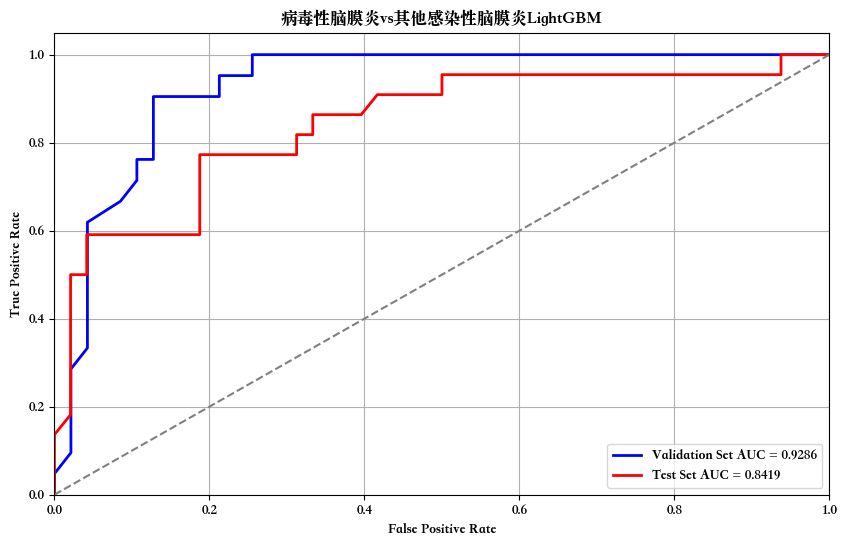

[0.8235,
 0.8462,
 0.5238,
 0.6471,
 0.9286,
 0.8143,
 0.7647,
 0.5909,
 0.6667,
 0.8419]

In [5]:

#注册中文字体到matplotlib
font_path = "/data/home/yansn/anaconda3/envs/naojiye/lib/python3.10/site-packages/matplotlib/mpl-data/fonts/ttf/Songti.ttc"
mpl.font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)
font_name = prop.get_name()
print("matplotlib 识别的字体名:", font_name)

plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False

# 预测验证集和测试集
y_val_pred = final_model.predict(X_val)
y_test_pred = final_model.predict(X_test)

# 预测验证集和测试集的概率（用于绘制 AUC 曲线）
y_val_prob = final_model.predict_proba(X_val)[:, 1]
y_test_prob = final_model.predict_proba(X_test)[:, 1]

# 计算准确率、精确率、召回率和F1分数
val_accuracy = accuracy_score(y_val, y_val_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

val_precision = precision_score(y_val, y_val_pred)
test_precision = precision_score(y_test, y_test_pred)

val_recall = recall_score(y_val, y_val_pred)
test_recall = recall_score(y_test, y_test_pred)

val_f1 = f1_score(y_val, y_val_pred)
test_f1 = f1_score(y_test, y_test_pred)

# 输出模型评估结果
print("Validation Set Performance:")
print(f"Accuracy: {val_accuracy:.4f}")
print(f"Precision: {val_precision:.4f}")
print(f"Recall: {val_recall:.4f}")
print(f"F1-Score: {val_f1:.4f}")

print("\nTest Set Performance:")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1-Score: {test_f1:.4f}")

# 绘制 ROC 曲线和 AUC
fpr_val, tpr_val, _ = roc_curve(y_val, y_val_prob)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_prob)

# 计算 AUC
roc_auc_val = auc(fpr_val, tpr_val)
roc_auc_test = auc(fpr_test, tpr_test)

# 绘制 ROC 曲线
plt.figure(figsize=(10, 6))
plt.plot(fpr_val, tpr_val, color='blue', lw=2, label=f'Validation Set AUC = {roc_auc_val:.4f}')
plt.plot(fpr_test, tpr_test, color='red', lw=2, label=f'Test Set AUC = {roc_auc_test:.4f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # 对角线
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('病毒性脑膜炎vs其他感染性脑膜炎LightGBM')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


[round(val_accuracy,4),round(val_precision,4),round(val_recall,4),round(val_f1,4),round(roc_auc_val,4),round(test_accuracy,4),round(test_precision,4),round(test_recall,4),round(test_f1,4),round(roc_auc_test,4)]



===== SHAP 特征重要性 (柱状图):  =====


/data/home/yansn/anaconda3/envs/naojiye/lib/python3.10/site-packages/shap/explainers/_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


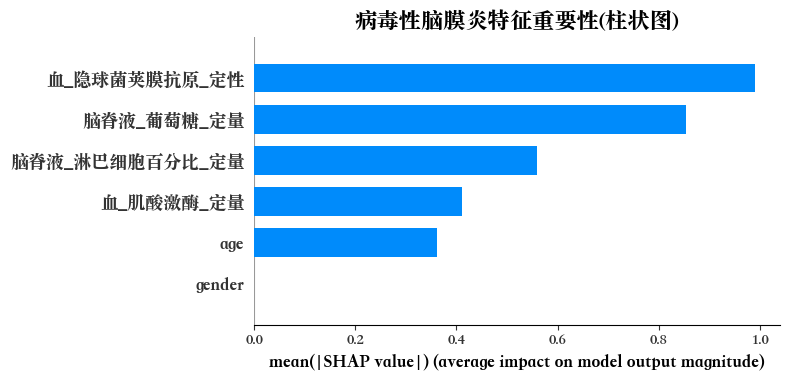


===== SHAP 特征分布 (蜂群图): =====


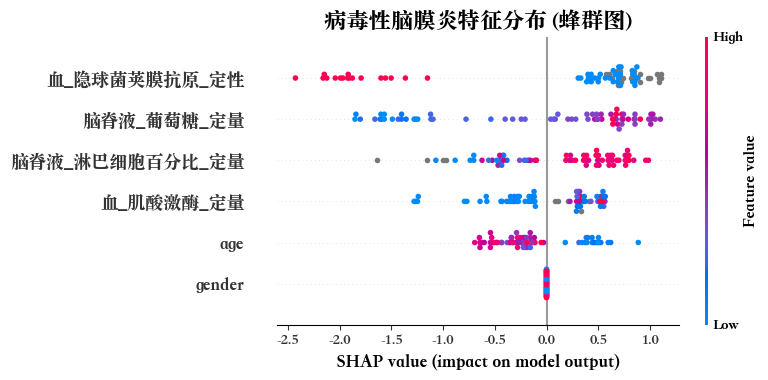

In [11]:

# ---------------- SHAP 分析 -----------------
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)
shap_matrix = shap_values[1] if isinstance(shap_values, list) else shap_values

print(f"\n===== SHAP 特征重要性 (柱状图):  =====")
plt.title("病毒性脑膜炎特征重要性(柱状图)", fontsize=16, fontweight='bold')
plt.tight_layout()
shap.summary_plot(shap_matrix, X_test, plot_type="bar", show=True)
plt.title("病毒性脑膜炎特征分布 (蜂群图)", fontsize=16, fontweight='bold')
plt.tight_layout()

print(f"\n===== SHAP 特征分布 (蜂群图): =====")
shap.summary_plot(shap_matrix, X_test, show=True)

/data/home/yansn/anaconda3/envs/naojiye/lib/python3.10/site-packages/shap/plots/_waterfall.py:279: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Songti SC.
  text_bbox = txt_obj.get_window_extent(renderer=renderer)


/data/home/yansn/anaconda3/envs/naojiye/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Songti SC.
  fig.canvas.print_figure(bytes_io, **kw)


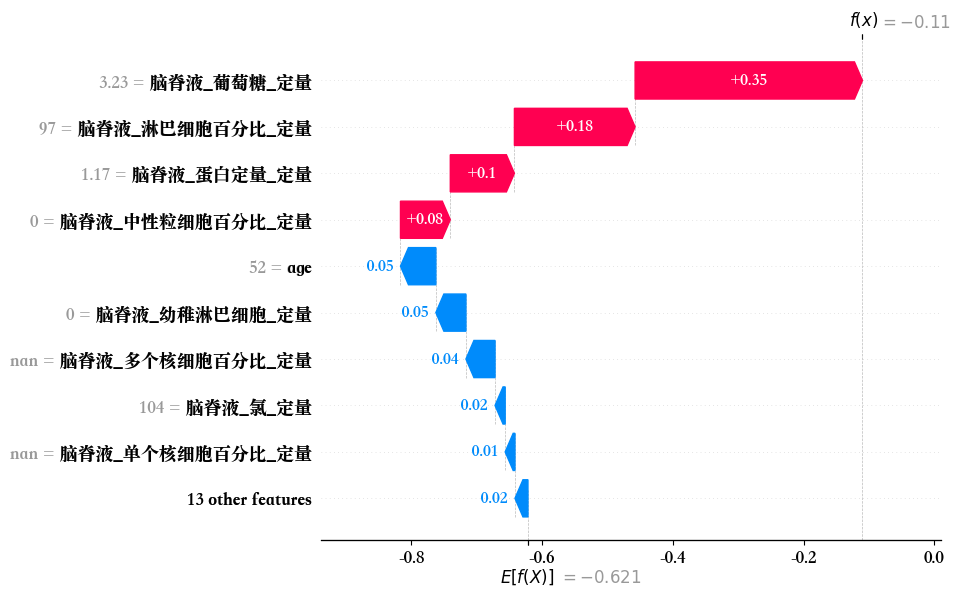

In [7]:
# 生成第一个样本的瀑布图
shap.plots.waterfall(shap.Explanation(values=shap_values[0], 
                                     base_values=explainer.expected_value, 
                                     data=X_test.iloc[0], 
                                     feature_names=X_test.columns))
plt.show()